In [112]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [114]:
x,y=make_blobs(n_samples=500,n_features=2,centers=5,random_state=3)

In [116]:
x

array([[-6.94238952e+00, -6.88072230e+00],
       [ 8.14492336e+00,  7.52724561e+00],
       [-3.61995355e+00, -7.72691339e-02],
       [-8.91918262e+00, -6.77218900e+00],
       [-7.37151112e+00, -5.05064290e+00],
       [-4.65743008e+00,  5.07750808e-02],
       [-9.85614721e+00, -1.94829844e+00],
       [-7.03064028e+00, -7.47212242e+00],
       [ 7.44598269e+00,  9.20313614e+00],
       [-6.74761638e+00, -5.40793452e+00],
       [ 8.73872704e+00,  5.97009465e+00],
       [-3.89871930e+00,  1.52191932e-01],
       [ 8.84851188e+00,  9.26501008e+00],
       [-6.83038032e+00, -7.68741713e+00],
       [-4.65780461e+00,  5.13396635e-01],
       [-9.14747586e+00, -5.83583269e+00],
       [ 8.27287322e+00,  6.92062212e+00],
       [-6.67147607e+00, -5.89031942e+00],
       [-7.33837507e+00, -5.96439930e+00],
       [ 6.96905011e+00,  6.34491640e+00],
       [ 1.87879015e+00,  3.51452443e+00],
       [ 1.46173901e+00,  3.38024741e+00],
       [-7.82304106e+00, -6.34230341e+00],
       [-3.

In [118]:
y

array([3, 2, 1, 3, 3, 1, 4, 3, 2, 3, 2, 1, 2, 3, 1, 3, 2, 3, 3, 2, 0, 0,
       3, 1, 3, 0, 4, 4, 1, 4, 3, 4, 0, 0, 3, 0, 2, 2, 3, 0, 0, 0, 4, 4,
       1, 2, 2, 1, 4, 4, 2, 3, 4, 3, 3, 0, 3, 3, 2, 1, 2, 1, 1, 3, 4, 2,
       1, 1, 0, 1, 0, 3, 0, 3, 0, 1, 3, 4, 0, 0, 1, 0, 1, 4, 2, 4, 1, 2,
       4, 1, 4, 0, 3, 0, 0, 2, 3, 1, 1, 0, 2, 0, 1, 1, 2, 2, 2, 1, 1, 3,
       2, 4, 3, 2, 1, 0, 2, 4, 0, 1, 2, 1, 4, 3, 0, 4, 4, 4, 3, 3, 1, 1,
       3, 2, 2, 4, 1, 4, 1, 3, 3, 0, 1, 2, 4, 3, 2, 2, 3, 1, 3, 3, 1, 1,
       2, 0, 0, 4, 1, 3, 0, 2, 4, 0, 2, 0, 2, 0, 0, 0, 4, 3, 0, 2, 0, 4,
       3, 1, 2, 4, 2, 3, 2, 0, 4, 4, 0, 3, 1, 2, 0, 1, 4, 3, 4, 0, 1, 4,
       3, 3, 3, 0, 0, 2, 3, 4, 4, 3, 2, 3, 3, 3, 0, 2, 1, 2, 3, 3, 2, 4,
       1, 4, 4, 0, 3, 1, 3, 1, 4, 0, 1, 1, 3, 0, 3, 0, 1, 2, 1, 0, 0, 2,
       3, 3, 1, 1, 0, 2, 0, 3, 4, 2, 4, 3, 4, 4, 4, 4, 2, 0, 2, 3, 0, 2,
       4, 1, 2, 2, 2, 4, 3, 3, 1, 0, 0, 2, 1, 1, 3, 1, 4, 1, 2, 2, 4, 3,
       0, 4, 4, 2, 0, 3, 1, 0, 1, 4, 1, 1, 2, 3, 0,

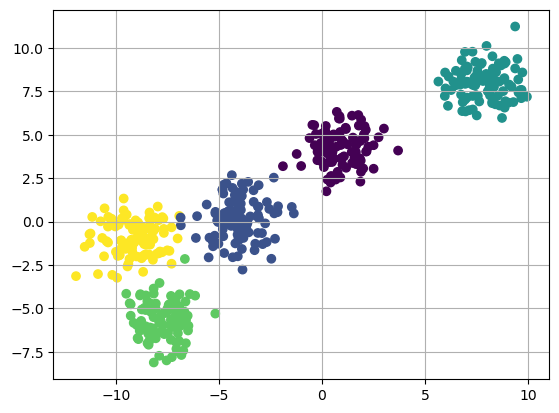

In [120]:
fig=plt.figure(0)
plt.grid(True)
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [189]:
k=5
colors=["green","yellow","blue","red","cyan"]

clusters={}

for idx in range(k):
    center=10*(2*np.random.random((x.shape[1],))-1)
    points=[]
    cluster={
        'center':center,
        'points':[],
        'color':colors[idx]
    }
    clusters[idx]=cluster

In [191]:
clusters

{0: {'center': array([7.96851013, 8.54461104]),
  'points': [],
  'color': 'green'},
 1: {'center': array([-3.33628848,  6.16934521]),
  'points': [],
  'color': 'yellow'},
 2: {'center': array([-9.08288254,  3.70811403]),
  'points': [],
  'color': 'blue'},
 3: {'center': array([-5.26257024,  0.95158875]),
  'points': [],
  'color': 'red'},
 4: {'center': array([-1.59283309, -9.40947366]),
  'points': [],
  'color': 'cyan'}}

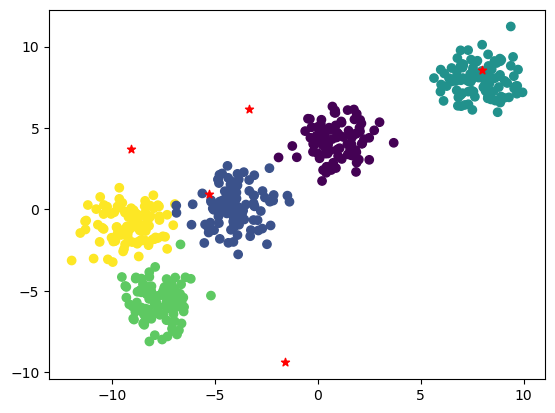

In [193]:
plt.scatter(x[:,0],x[:,1],c=y)
for i in clusters:
    center=clusters[i]["center"]
    plt.scatter(center[0],center[1],marker="*",c="red")
plt.show()

In [128]:
def distance(v1,v2):
    return np.sqrt(np.sum((v1-v2)**2))

In [130]:
v1=np.array([1,2])
v2=np.array([3,3])
distance(v1,v2)

2.23606797749979

In [195]:
## Implementing e step

def assign_cluster():
     for idx in range (x.shape[0]):
         dist=[]
     
         cur_x=x[idx]
         
         for i in range (k):
             dis=distance(cur_x,clusters[i]['center'])
             dist.append(dis)
         cur_cluster=np.argmin(dist)
         clusters[cur_cluster]['points'].append(cur_x)


## Implementing the M-Step
def update_cluster():
    for idx in range(k):
        pts=np.array(clusters[idx]['points'])
        if(pts.shape[0]>0):
            new_center=pts.mean(axis=0)
            clusters[idx]['center']=new_center

            clusters[idx]["points"]=[]


def plot_cluster():
    for i in clusters:
        pts=np.array(clusters[i]["points"])
        try:
            plt.scatter(pts[:,0],pts[:,1],c=clusters[i]['color'])
        except:
            pass
        center=plt.scatter(clusters[i]['center'][0],clusters[i]['center'][1],c="black",marker="*")

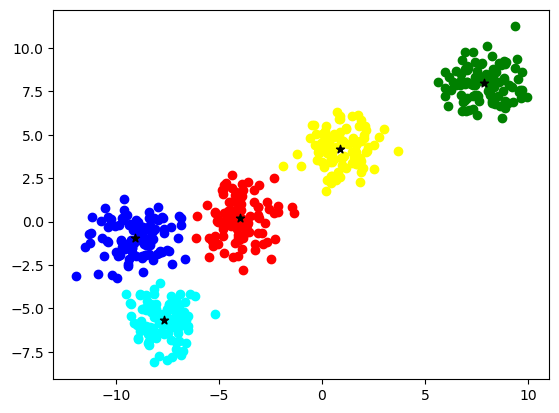

In [205]:
assign_cluster()
plot_cluster()
update_cluster()

# KMeans Clusterig library

In [209]:
from sklearn.cluster import KMeans

In [213]:
km=KMeans(n_clusters=5)

In [215]:
x,y=make_blobs(n_samples=500,n_features=2,centers=5,random_state=3)

In [217]:
km.fit(x,y)

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=5)

In [219]:
centers=km.cluster_centers_

In [221]:
centers

array([[-3.97953526,  0.19458336],
       [ 7.8649674 ,  7.97988109],
       [ 0.88641907,  4.19441853],
       [-7.6726196 , -5.69211059],
       [-9.0671623 , -0.96740759]])

In [223]:
labels=km.labels_

In [225]:
print(labels)

[3 1 0 3 3 0 4 3 1 3 1 0 1 3 0 3 1 3 3 1 2 2 3 0 3 2 4 4 0 4 3 4 2 2 3 2 1
 1 3 2 2 2 4 4 0 1 1 4 4 4 1 3 4 3 3 2 3 3 1 0 1 0 0 3 4 1 0 0 2 0 2 3 2 3
 2 0 3 4 2 2 0 2 0 4 1 4 0 1 4 0 4 2 3 2 2 1 3 0 0 2 1 2 0 0 1 1 1 0 0 3 1
 4 3 1 0 2 1 4 2 0 1 0 4 3 2 4 4 4 3 3 0 0 3 1 1 4 0 4 0 3 3 2 0 1 4 3 1 1
 3 0 3 3 0 0 1 2 2 4 0 3 2 1 4 2 1 2 1 2 2 2 4 3 2 1 2 4 3 0 1 4 1 3 1 2 4
 4 2 3 0 1 2 0 4 3 4 2 0 4 3 3 3 2 2 1 3 4 4 3 1 3 3 3 2 1 0 1 3 3 1 4 0 4
 4 2 3 0 3 0 4 2 0 0 3 2 3 2 0 1 0 2 2 1 3 3 0 0 2 1 2 3 4 1 4 3 4 4 4 4 1
 2 1 3 2 1 4 0 1 1 1 4 3 3 0 2 2 1 0 0 3 0 4 0 1 1 4 4 2 4 4 1 2 3 0 2 0 4
 0 0 1 3 2 1 2 2 3 4 2 0 2 4 3 3 0 1 2 4 1 2 0 4 1 4 3 2 4 0 0 2 2 2 3 4 2
 3 1 0 0 4 1 1 0 0 4 2 2 2 3 4 1 4 3 2 1 1 0 2 2 4 2 4 0 0 0 4 2 3 2 0 4 4
 1 3 1 4 3 4 0 1 2 1 0 3 3 1 1 2 1 2 4 0 1 4 3 3 1 0 2 4 3 3 3 4 1 2 1 1 1
 4 2 0 1 0 0 4 0 3 0 3 1 2 2 3 1 4 3 2 0 1 4 0 4 4 1 4 0 4 1 4 0 4 3 2 2 4
 2 1 2 2 4 3 3 0 4 2 0 4 0 1 0 1 3 2 0 3 0 3 3 2 3 2 4 1 1 0 3 3 4 4 1 4 4
 1 4 1 1 1 4 2 4 0 1 0 0 

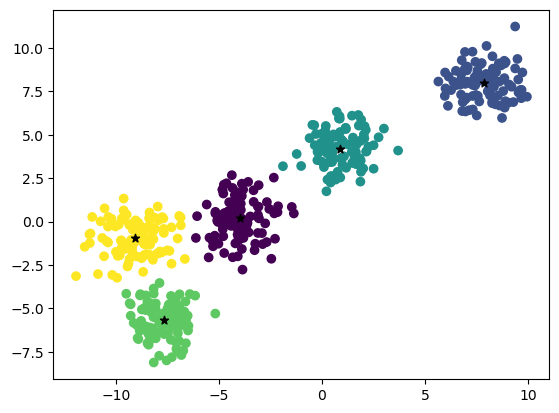

In [235]:
plt.scatter(x[:,0],x[:,1],c=labels)
plt.scatter(centers[:,0],centers[:,1],c="black",marker="*")
plt.show()